In [1]:
# Residues involved in PTC based on The Ribosomal Peptidyl Transferase Center:
# Structure, Function, Evolution, Inhibition

In [1]:
import os
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt

# Residues involved in PTC based on The Ribosomal Peptidyl Transferase Center:
# Structure, Function, Evolution, Inhibition
# A2058 -> G3904 | A2059 -> A3905 | G2061 -> G3907  | C2063 -> C3909
# G2251 -> G4196 | G2252 -> G4197 | G2447 -> G4393  | A2450 -> A4396
# A2451 -> A4397 | A2453 -> U4399 | C2499 -> U4445  | C2501 -> C4447
# U2506 -> U4452 | G2553 -> G4499 | A2572 -> A4518  | U2583 -> G4529
# U2585 -> U4531 | A2602 -> A4548

# Standard E. coli numbering for the PTC core
ptc_ref_list = np.array([
    2058, 2059, 2061, 2063, 2251, 2252, 2447, 2450, 2451, 
    2453, 2499, 2501, 2506, 2553, 2572, 2583, 2585, 2602
])

path = "/home/twlodarski/Projects/ribosome_tunnels/new_code/data_new/"
os.chdir(path)

In [2]:
# Bacteria ribosomes PTC mapping
org_data_bacteria = {
    "E.coli_B": {
        "pdb": "ecoli/ecoli_tunnel_fix.pdb", 
        "residues": {2058:2058, 2059:2059, 2061:2061, 2063:2063, 2251:2251, 2252:2252, 2447:2447, 2450:2450, 2451:2451, 2453:2453, 2499:2499, 2501:2501, 2506:2506, 2553:2553, 2572:2572, 2583:2583, 2585:2585, 2602:2602}
    },
    "A.baumannii_B": {
        "pdb": "abau/6v39_tunnel_fix.pdb", 
        "residues": {2058:2054, 2059:2055, 2061:2057, 2063:2059, 2251:2247, 2252:2248, 2447:2443, 2450:2446, 2451:2447, 2453:2449, 2499:2495, 2501:2497, 2506:2502, 2553:2549, 2572:2568, 2583:2579, 2585:2581, 2602:2598} 
    },
    "B.burgdorferi_B": {
        "pdb": "bbur/8fn2_tunnel_fix.pdb", 
        "residues": {2058:2112, 2059:2113, 2061:2115, 2063:2117, 2251:2297, 2252:2298, 2447:2493, 2450:2496, 2451:2497, 2453:2499, 2499:2545, 2501:2547, 2506:2552, 2553:2599, 2572:2618, 2583:2629, 2585:2631, 2602:2648}
    }, 
    "B.subtilis_B": {
        "pdb": "bsub/7as8_tunnel_fix.pdb", 
        "residues": {2058:2087, 2059:2088, 2061:2090, 2063:2092, 2251:2280, 2252:2281, 2447:2476, 2450:2479, 2451:2480, 2453:2482, 2499:2528, 2501:2530, 2506:2535, 2553:2582, 2572:2601, 2583:2612, 2585:2614, 2602:2631}
    },
    # "cacn_B": {
    #     "pdb": "cacn/8crx_tunnel_fix.pdb",
    #     "residues": {2058:2241, 2059:2242, 2061:2244, 2063:2246, 2251:2433, 2252:2434, 2447:2629, 2450:2632, 2451:2633, 2453:2635, 2499:2681, 2501:2683, 2506:2688, 2553:2735, 2572:2754, 2583:2765, 2585:2767, 2602:2784}
    # },
    "D.radiodurans_B": {
        "pdb": "drad/5dm6_tunnel_fix.pdb",
        "residues": {2058:2058, 2059:2059, 2061:2061, 2063:2063, 2251:2251, 2252:2252, 2447:2447, 2450:2450, 2451:2451, 2453:2453, 2499:2499, 2501:2501, 2506:2506, 2553:2553, 2572:2572, 2583:2583, 2585:np.nan, 2602:2602}
    },
    "E.faecalis_B": {
        "pdb": "efae/7p7u_tunnel_fix.pdb",
        "residues": {2058:2071, 2059:2072, 2061:2074, 2063:2076, 2251:2264, 2252:2265, 2447:2460, 2450:2463, 2451:2464, 2453:2466, 2499:2512, 2501:2514, 2506:2519, 2553:2566, 2572:2585, 2583:2596, 2585:2598, 2602:2615}
    },
    "F.johnsoniae_B": {
        "pdb": "fjoh/7jil_tunnel_fix.pdb",
        "residues": {2058:2065, 2059:2066, 2061:2068, 2063:2070, 2251:2249, 2252:2250, 2447:2445, 2450:2448, 2451:2449, 2453:2451, 2499:2497, 2501:2499, 2506:2504, 2553:2551, 2572:2570, 2583:2581, 2585:np.nan, 2602:2600}
    },
    "L.innocua_B": {
        "pdb": "linn/8uu5_tunnel_fix.pdb",
        "residues": {2058:2091, 2059:2092, 2061:2094, 2063:2096, 2251:2284, 2252:2285, 2447:2480, 2450:2483, 2451:2484, 2453:2486, 2499:2532, 2501:2534, 2506:2539, 2553:2586, 2572:2605, 2583:2616, 2585:2618, 2602:2635}
    },
    "L.lactis_B": {
        "pdb": "llac/5myj_tunnel_fix.pdb",
        "residues": {2058:2062, 2059:2063, 2061:2065, 2063:2067, 2251:2255, 2252:2256, 2447:2451, 2450:2454, 2451:2455, 2453:2457, 2499:2503, 2501:2505, 2506:2510, 2553:2557, 2572:2576, 2583:2587, 2585:2589, 2602:2606}
    },
    "L.monocytogenes_B": {
        "pdb": "lmon/8a63_tunnel_fix.pdb",
        "residues": {2058:2091, 2059:2092, 2061:2094, 2063:2096, 2251:2284, 2252:2285, 2447:2480, 2450:2483, 2451:2484, 2453:2486, 2499:2532, 2501:2534, 2506:2539, 2553:2586, 2572:2605, 2583:2616, 2585:2618, 2602:2635}
    },
    "M.pneumoniae_B": {
        "pdb": "mpne/7pal_tunnel_fix.pdb",
        "residues": {2058:2065, 2059:2066, 2061:2068, 2063:2070, 2251:2259, 2252:2260, 2447:2455, 2450:2458, 2451:2459, 2453:2461, 2499:2507, 2501:2509, 2506:2514, 2553:2561, 2572:2580, 2583:2591, 2585:2593, 2602:2610}
    },
    "M.smegmatis_B": {
        "pdb": "msme/8fr8_tunnel_fix.pdb",
        "residues": {2058:2282, 2059:2283, 2061:2285, 2063:2287, 2251:2475, 2252:2476, 2447:2671, 2450:2674, 2451:2675, 2453:2677, 2499:2723, 2501:2725, 2506:2730, 2553:2777, 2572:2796, 2583:2807, 2585:2809, 2602:2826}
    },
    "M.tuberculosis_B": {
        "pdb": "mtub/7mt7_tunnel_fix.pdb",
        "residues": {2058:2296, 2059:2297, 2061:2299, 2063:2301, 2251:2489, 2252:2490, 2447:2685, 2450:2688, 2451:2689, 2453:2691, 2499:2737, 2501:2739, 2506:2744, 2553:2791, 2572:2810, 2583:2821, 2585:2823, 2602:2840}
    },
    "P.aeruginosa_B": {
        "pdb": "paer/6spd_tunnel_fix.pdb",
        "residues": {2058:2045, 2059:2046, 2061:2048, 2063:2050, 2251:2238, 2252:2239, 2447:2434, 2450:2437, 2451:2438, 2453:2440, 2499:2486, 2501:2488, 2506:2493, 2553:2540, 2572:2559, 2583:2570, 2585:2572, 2602:2589}
    },
    "P.gingivalis_B": {
        "pdb": "pgin/9i5x_tunnel_fix.pdb",
        "residues": {2058:2068, 2059:2069, 2061:2071, 2063:2073, 2251:2252, 2252:2253, 2447:2448, 2450:2451, 2451:2452, 2453:2454, 2499:2500, 2501:2502, 2506:2507, 2553:np.nan, 2572:2573, 2583:2584, 2585:2586, 2602:2603}
    },    
    "P.urativorans_B": {
        "pdb": "pura/8rdv_tunnel_fix.pdb",
        "residues": {2058:2044, 2059:2045, 2061:2047, 2063:2049, 2251:2234, 2252:2235, 2447:2430, 2450:2433, 2451:2434, 2453:2436, 2499:2482, 2501:2484, 2506:2489, 2553:2536, 2572:2555, 2583:2566, 2585:2568, 2602:2585}
    },
    "S.aureus_B": {
        "pdb": "saur/6hma_tunnel_fix.pdb",
        "residues": {2058:2085, 2059:2086, 2061:2088, 2063:2090, 2251:2278, 2252:2279, 2447:2474, 2450:2477, 2451:2478, 2453:2480, 2499:2526, 2501:2528, 2506:2533, 2553:2580, 2572:2599, 2583:2610, 2585:np.nan, 2602:2629}
    },
    "S.fradiae_B": {
        "pdb": "sfra/9qt5_tunnel_fix.pdb",
        "residues": {2058:2278, 2059:2279, 2061:2281, 2063:2283, 2251:2470, 2252:2471, 2447:2666, 2450:2669, 2451:2670, 2453:2672, 2499:2718, 2501:2720, 2506:2725, 2553:2772, 2572:2791, 2583:2801, 2585:2804, 2602:2821}
    },
    "T.thermophilus_B": {
        "pdb": "tthe/8cvl_tunnel_fix.pdb",
        "residues": {2058:2058, 2059:2059, 2061:2061, 2063:2063, 2251:2251, 2252:2252, 2447:2447, 2450:2450, 2451:2451, 2453:2453, 2499:2499, 2501:2501, 2506:2506, 2553:2553, 2572:2572, 2583:2583, 2585:2585, 2602:2602}
    },
    "V.natrigens_B": {
        "pdb": "vnat/9h91_tunnel_fix.pdb",
        "residues": {2058:2044, 2059:2045, 2061:2047, 2063:2049, 2251:2237, 2252:2238, 2447:2433, 2450:2436, 2451:2437, 2453:2439, 2499:2485, 2501:2487, 2506:2492, 2553:2539, 2572:2558, 2583:2569, 2585:2571, 2602:2588}
    }
}

In [3]:
# Archaea ribosomes PTC mapping
org_data_archaea = {
    "H.marismortui_A": {
        "pdb": "hmar/1s72_tunnel_fix.pdb",
        "residues": {2058:2099, 2059:2100, 2061:2102, 2063:2104, 2251:2284, 2252:2285, 2447:2482, 2450:2485, 2451:2486, 2453:2488, 2499:2534, 2501:2536, 2506:2541, 2553:2588, 2572:2607, 2583:2618, 2585:2620, 2602:2637}
    },
    "M.acetivorans_A": {
        "pdb": "mace/9zng_tunnel_fix.pdb",
        "residues": {2058:2083, 2059:2084, 2061:2086, 2063:2088, 2251:2264, 2252:2265, 2447:2462, 2450:2465, 2451:2466, 2453:2468, 2499:2514, 2501:2516, 2506:2521, 2553:2568, 2572:2587, 2583:2598, 2585:2600, 2602:2617}
    },    
    "P.calidifontis_A": {
        "pdb": "pcal/9e71_tunnel_fix.pdb",
        "residues": {2058:2178, 2059:2179, 2061:2181, 2063:2183, 2251:2362, 2252:2363, 2447:2561, 2450:2564, 2451:2565, 2453:2567, 2499:2613, 2501:2615, 2506:2620, 2553:2667, 2572:2687, 2583:2697, 2585:2699, 2602:2716}
    },
    "P.furiosus_A": {
        "pdb": "pfur/4v6u_tunnel_fix.pdb",
        "residues": {2058:2181, 2059:2182, 2061:2184, 2063:2186, 2251:2364, 2252:2365, 2447:2562, 2450:2565, 2451:2566, 2453:2568, 2499:2614, 2501:2616, 2506:2621, 2553:2668, 2572:2687, 2583:2698, 2585:2700, 2602:2717}
    },
    "S.acidocaldarius_A": {
        "pdb": "saci/8hku_tunnel_fix.pdb",
        "residues": {2058:2187, 2059:2188, 2061:2190, 2063:2192, 2251:2372, 2252:2373, 2447:2571, 2450:2574, 2451:2575, 2453:2577, 2499:2623, 2501:2625, 2506:2630, 2553:2677, 2572:2696, 2583:2707, 2585:2709, 2602:2726}
    },
    "T.kodakarensis_A": {
        "pdb": "tkod/6th6_tunnel_fix.pdb",
        "residues": {2058:2170, 2059:2171, 2061:2173, 2063:2175, 2251:2353, 2252:2354, 2447:2551, 2450:2554, 2451:2555, 2453:2557, 2499:2603, 2501:2605, 2506:2610, 2553:2657, 2572:2676, 2583:2687, 2585:2689, 2602:2706}
    }
}

In [44]:
# Eukaryota ribosomes PTC mapping
org_data_eukaryota = {
    "A.thaliana_E": {
        "pdb": "atha/9h3g_tunnel_fix.pdb",
        "residues": {2058:2398, 2059:2399, 2061:2401, 2063:2403, 2251:2618, 2252:2619, 2447:2815, 2450:2818, 2451:2819, 2453:2821, 2499:2867, 2501:2869, 2506:2874, 2553:2921, 2572:2940, 2583:2951, 2585:2953, 2602:2970}
    },    
    "C.albicans_E": {
        "pdb": "calb/7pzy_tunnel_fix.pdb",
        "residues": {2058:2378, 2059:2379, 2061:2381, 2063:2383, 2251:2591, 2252:2592, 2447:2788, 2450:2791, 2451:2792, 2453:2794, 2499:2840, 2501:2842, 2506:2847, 2553:2894, 2572:2913, 2583:2924, 2585:2926, 2602:2943}
    },
    "C.elegans_E": {
        "pdb": "cele/9bh5_tunnel_fix.pdb",
        "residues": {2058:2503, 2059:2504, 2061:2506, 2063:2508, 2251:2731, 2252:2732, 2447:2928, 2450:2931, 2451:2932, 2453:2934, 2499:2980, 2501:2982, 2506:2987, 2553:3034, 2572:3053, 2583:3064, 2585:3066, 2602:3083}
    },
    "C.porcellus_E": {
        "pdb": "cpor/9y4h_tunnel_fix.pdb",
        "residues": {2058:3904, 2059:3905, 2061:3907, 2063:3909, 2251:4196, 2252:4197, 2447:4393, 2450:4396, 2451:4397, 2453:4399, 2499:4445, 2501:4447, 2506:4453, 2553:4499, 2572:4518, 2583:4529, 2585:4531, 2602:4548}
    },
    "C.sericeus_E": {
        "pdb": "cser/9y49_tunnel_fix.pdb",
        "residues": {2058:3904, 2059:3905, 2061:3907, 2063:3909, 2251:4196, 2252:4197, 2447:4393, 2450:4396, 2451:4397, 2453:4399, 2499:4445, 2501:4447, 2506:4453, 2553:4499, 2572:4518, 2583:4529, 2585:4531, 2602:4548}
    },
    "C.thermophilia_E": {
        "pdb": "cthe/7old_tunnel_fix.pdb",
        "residues": {2058:2363, 2059:2364, 2061:2366, 2063:2368, 2251:2578, 2252:2579, 2447:2775, 2450:2778, 2451:2779, 2453:2781, 2499:2827, 2501:2829, 2506:2834, 2553:2881, 2572:2900, 2583:2911, 2585:2913, 2602:2930}
    },
    "D.melanogaster_E": { # Fixed typo here from D.melanogaste_E
        "pdb": "dmel/4v6w_tunnel_fix.pdb",
        "residues": {2058:2778, 2059:2779, 2061:2781, 2063:2783, 2251:3151, 2252:3152, 2447:3348, 2450:3351, 2451:3352, 2453:3354, 2499:3400, 2501:3402, 2506:3407, 2553:3454, 2572:3473, 2583:3483, 2585:3485, 2602:3502}
    },
    "D.rerio_E": {
        "pdb": "drer/7oyb_tunnel_fix.pdb",
        "residues": {2058:3164, 2059:3165, 2061:3167, 2063:3169, 2251:3464, 2252:3465, 2447:3661, 2450:3664, 2451:3665, 2453:3667, 2499:3713, 2501:3715, 2506:3720, 2553:3767, 2572:3786, 2583:3797, 2585:3799, 2602:3816}
    },
    "E.cuniculi_E": {
        "pdb": "ecun/7qep_tunnel_fix.pdb",
        "residues": {2058:1766, 2059:1767, 2061:1769, 2063:1771, 2251:2000, 2252:2001, 2447:2195, 2450:2198, 2451:2199, 2453:2201, 2499:2247, 2501:2249, 2506:2254, 2553:2301, 2572:2320, 2583:2331, 2585:2333, 2602:2350}
    },
    "E.gracilis_E": {
        "pdb": "egra/6zj3_tunnel_fix.pdb",
        "residues": {2058:2888, 2059:2889, 2061:2891, 2063:2893, 2251:3191, 2252:3192, 2447:3402, 2450:3405, 2451:3406, 2453:3408, 2499:3454, 2501:3456, 2506:3461, 2553:3509, 2572:3528, 2583:3539, 2585:3541, 2602:3558}
    },
    "E.histolytica_E": {
        "pdb": "ehis/9v21_tunnel_fix.pdb",
        "residues": {2058:2476, 2059:2477, 2061:2479, 2063:2481, 2251:2689, 2252:2690, 2447:2959, 2450:2962, 2451:2963, 2453:2965, 2499:3011, 2501:3013, 2506:3018, 2553:3065, 2572:3084, 2583:3095, 2585:3097, 2602:3114}
    },
    "G.lamblia_E": {
        "pdb": "glam/7pwg_tunnel_fix.pdb",
        "residues": {2058:1887, 2059:1888, 2061:1890, 2063:1892, 2251:2042, 2252:2043, 2447:2238, 2450:2241, 2451:2242, 2453:2244, 2499:2290, 2501:2292, 2506:2297, 2553:2344, 2572:2362, 2583:2373, 2585:2375, 2602:np.nan}
    },
    "G.gallus_E": {
        "pdb": "ggal/8q7z_tunnel_fix.pdb",
        "residues": {2058:3381, 2059:3382, 2061:3384, 2063:3386, 2251:3639, 2252:3640, 2447:3836, 2450:3839, 2451:3840, 2453:3842, 2499:3888, 2501:3890, 2506:3895, 2553:3942, 2572:3961, 2583:3972, 2585:3974, 2602:3991}
    },
    "H.glaber_E": {
        "pdb": "hgla/9y44_tunnel_fix.pdb",
        "residues": {2058:3904, 2059:3905, 2061:3907, 2063:3909, 2251:4196, 2252:4197, 2447:4393, 2450:4396, 2451:4397, 2453:4399, 2499:4445, 2501:4447, 2506:4452, 2553:4499, 2572:4518, 2583:4529, 2585:np.nan, 2602:4548}
    },
    "H.sapiens_E": {
        "pdb": "hsap/8jdk_tunnel_fix.pdb",
        "residues": {2058:3904, 2059:3905, 2061:3907, 2063:3909, 2251:4196, 2252:4197, 2447:4393, 2450:4396, 2451:4397, 2453:4399, 2499:4445, 2501:4447, 2506:4452, 2553:4499, 2572:4518, 2583:4529, 2585:4531, 2602:4548}
    },
    "K.lactis_E": {
        "pdb": "klac/6uz7_tunnel_fix.pdb",
        "residues": {2058:2369, 2059:2370, 2061:2372, 2063:2374, 2251:2587, 2252:2588, 2447:2784, 2450:2787, 2451:2788, 2453:2790, 2499:2836, 2501:2838, 2506:2843, 2553:2890, 2572:2909, 2583:2920, 2585:2922, 2602:2939}
    },
    "L.donovani_E": {
        "pdb": "ldon/5t2a_tunnel_fix.pdb",
        "residues": {2058:583, 2059:584, 2061:586, 2063:588, 2251:982, 2252:983, 2447:1190, 2450:1193, 2451:1194, 2453:1196, 2499:1242, 2501:1244, 2506:1249, 2553:1296, 2572:1315, 2583:1326, 2585:1328, 2602:1345}
    },
    "L.major_E": {
        "pdb": "lmaj/8a3w_tunnel_fix.pdb",
        "residues": {2058:646, 2059:647, 2061:649, 2063:651, 2251:1046, 2252:1047, 2447:1254, 2450:1257, 2451:1258, 2453:np.nan, 2499:1306, 2501:1308, 2506:1313, 2553:1360, 2572:1379, 2583:1390, 2585:1392, 2602:1409}
    },
    "M.musculus_E": {
        "pdb": "mmus/7ls2_tunnel_fix.pdb",
        "residues": {2058:3560, 2059:3561, 2061:3563, 2063:3565, 2251:3848, 2252:3849, 2447:4045, 2450:4048, 2451:4049, 2453:4051, 2499:4097, 2501:4099, 2506:4104, 2553:4151, 2572:4170, 2583:4181, 2585:4183, 2602:4200}
    },
    "N.crasa_E": {
        "pdb": "ncra/7r81_tunnel_fix.pdb",
        "residues": {2058:2364, 2059:2365, 2061:2367, 2063:2369, 2251:2579, 2252:2580, 2447:2776, 2450:2779, 2451:2780, 2453:2782, 2499:2828, 2501:2830, 2506:2835, 2553:2882, 2572:2901, 2583:2912, 2585:2914, 2602:2931}
    },
    "N.tabacum_E": {
        "pdb": "ntab/8b2l_tunnel_fix.pdb",
        "residues": {2058:2403, 2059:2404, 2061:2406, 2063:2408, 2251:2622, 2252:2623, 2447:2819, 2450:2822, 2451:2823, 2453:2825, 2499:2871, 2501:2873, 2506:2878, 2553:2925, 2572:2944, 2583:2955, 2585:2957, 2602:2974}
    },
    "O.cuniculus_E": {
        "pdb": "ocun/6sgc_tunnel_fix.pdb",
        "residues": {2058:3904, 2059:3905, 2061:3907, 2063:3909, 2251:4196, 2252:4197, 2447:4393, 2450:4396, 2451:4397, 2453:4399, 2499:4445, 2501:4447, 2506:4452, 2553:4499, 2572:4518, 2583:4529, 2585:4531, 2602:4548}
    },
    "P.falciparum_E": {
        "pdb": "pfal/3jbn_tunnel_fix.pdb",
        "residues": {2058:2693, 2059:2694, 2061:2696, 2063:2698, 2251:2958, 2252:2959, 2447:3175, 2450:3178, 2451:3179, 2453:3181, 2499:3227, 2501:3229, 2506:3234, 2553:3281, 2572:3300, 2583:3311, 2585:3313, 2602:3330}
    },
    "P.locustae_E": {
        "pdb": "ploc/ribosome_tunnel_fix.pdb",
        "residues": {2058:1869, 2059:1870, 2061:1872, 2063:1874, 2251:2016, 2252:2017, 2447:2207, 2450:2210, 2451:2211, 2453:2213, 2499:2259, 2501:2261, 2506:2266, 2553:2313, 2572:2332, 2583:2343, 2585:2345, 2602:2362}
    },
    "R.norvegicus_E": {
        "pdb": "rnor/7qgg_tunnel_fix.pdb",
        "residues": {2058:3639, 2059:3640, 2061:3642, 2063:3644, 2251:3928, 2252:3929, 2447:4125, 2450:4128, 2451:4129, 2453:4131, 2499:4177, 2501:4179, 2506:4184, 2553:4231, 2572:4250, 2583:4261, 2585:4263, 2602:4280}
    },
    "S.cerevisiae_E": {
        "pdb": "scer/8ccs_tunnel_fix.pdb",
        "residues": {2058:2400, 2059:2401, 2061:2403, 2063:2405, 2251:2619, 2252:2620, 2447:2816, 2450:2819, 2451:2820, 2453:2822, 2499:2868, 2501:2870, 2506:2875, 2553:2922, 2572:2941, 2583:2952, 2585:2954, 2602:2971}
    },
    "S.lophii_E": {
        "pdb": "slop/7qca_tunnel_fix.pdb",
        "residues": {2058:1835, 2059:1836, 2061:1838, 2063:1840, 2251:1990, 2252:1991, 2447:2184, 2450:2187, 2451:2188, 2453:2190, 2499:2236, 2501:2238, 2506:2243, 2553:2290, 2572:2309, 2583:2320, 2585:2322, 2602:2339}
    },
    "S.lycoperscium_E": {
        "pdb": "slyc/7qiz_tunnel_fix.pdb",
        "residues": {2058:2403, 2059:2404, 2061:2406, 2063:2408, 2251:2623, 2252:2624, 2447:2820, 2450:2823, 2451:2824, 2453:2826, 2499:2872, 2501:2874, 2506:2879, 2553:2926, 2572:2945, 2583:2956, 2585:2958, 2602:2975}
    },
    "S.pombe_E": {
        "pdb": "spom/8eug_tunnel_fix.pdb",
        "residues": {2058:2488, 2059:2489, 2061:2491, 2063:2493, 2251:2714, 2252:2715, 2447:2911, 2450:2914, 2451:2915, 2453:2917, 2499:2963, 2501:2965, 2506:2970, 2553:3017, 2572:3036, 2583:3047, 2585:3049, 2602:3066}
    },
    "S.scrofa_E": {
        "pdb": "sscr/3j7p_tunnel_fix.pdb",
        "residues": {2058:3904, 2059:3905, 2061:3907, 2063:3909, 2251:4196, 2252:4197, 2447:4393, 2450:4396, 2451:4397, 2453:4399, 2499:4445, 2501:4447, 2506:4452, 2553:4499, 2572:4518, 2583:4529, 2585:4531, 2602:4548}
    },
    "T.aestivum_E": {
        "pdb": "taes/4v7e_tunnel_fix.pdb",
        "residues": {2058:2399, 2059:2400, 2061:2402, 2063:2404, 2251:2622, 2252:2623, 2447:2818, 2450:2821, 2451:2822, 2453:2824, 2499:2870, 2501:2872, 2506:2877, 2553:2924, 2572:2943, 2583:2954, 2585:2956, 2602:2973}
    },
    "T.brucei_E": {
        "pdb": "tbru/8ova_tunnel_fix.pdb",
        "residues": {2058:664, 2059:665, 2061:667, 2063:669, 2251:1062, 2252:1063, 2447:1270, 2450:1273, 2451:1274, 2453:1276, 2499:1322, 2501:1324, 2506:1329, 2553:1376, 2572:1395, 2583:1406, 2585:1408, 2602:1425}
    },
    "T.cruzi_E": {
        "pdb": "tcru/5t5h_tunnel_fix.pdb",
        "residues": {2058:746, 2059:747, 2061:749, 2063:751, 2251:1178, 2252:1179, 2447:1386, 2450:1389, 2451:1390, 2453:1392, 2499:1438, 2501:1440, 2506:1445, 2553:1492, 2572:1511, 2583:1522, 2585:1524, 2602:1541}
    },
    "T.gondii_E": {
        "pdb": "tgon/5xxb_tunnel_fix.pdb",
        "residues": {2058:2513, 2059:2514, 2061:2516, 2063:2518, 2251:2730, 2252:2731, 2447:2927, 2450:2930, 2451:2931, 2453:2933, 2499:2979, 2501:2981, 2506:2986, 2553:3033, 2572:3052, 2583:3063, 2585:3065, 2602:3082}
    },
    "T.thermophila_E": {
        "pdb": "tthe/4v8p_tunnel_fix.pdb",
        "residues": {2058:2395, 2059:2396, 2061:2398, 2063:2400, 2251:2608, 2252:2609, 2447:2804, 2450:2807, 2451:2808, 2453:2810, 2499:2856, 2501:2858, 2506:2863, 2553:2910, 2572:2929, 2583:2940, 2585:2942, 2602:2959}
    },
    "T.vaginalis_E": {
        "pdb": "tvag/5xy3_tunnel_fix.pdb",
        "residues": {2058:1918, 2059:1919, 2061:1921, 2063:1923, 2251:2073, 2252:2074, 2447:2272, 2450:2275, 2451:2276, 2453:2278, 2499:2324, 2501:2326, 2506:2331, 2553:2378, 2572:2396, 2583:2407, 2585:2409, 2602:2426}
    },
    "V.necatrix_E": {
        "pdb": "vnec/6rm3_tunnel_fix.pdb",
        "residues": {2058:1761, 2059:1762, 2061:1764, 2063:1766, 2251:1894, 2252:1895, 2447:2085, 2450:2088, 2451:2089, 2453:2091, 2499:2137, 2501:2139, 2506:2144, 2553:2191, 2572:2210, 2583:2221, 2585:2223, 2602:2240}
    },
    "X.laevis_E": {
        "pdb": "xlae/7oyc_tunnel_fix.pdb",
        "residues": {2058:3069, 2059:3070, 2061:3072, 2063:3074, 2251:3321, 2252:3322, 2447:3518, 2450:3521, 2451:3522, 2453:3524, 2499:3570, 2501:3572, 2506:3577, 2553:3624, 2572:3643, 2583:3654, 2585:3656, 2602:3673}
    }
}

In [45]:
# Combine all dictionaries into one meta-dictionary
all_domains = {
    "bacteria": org_data_bacteria,
    "archaea": org_data_archaea,
    "eukaryota": org_data_eukaryota,
    # "chloro": org_data_chloro  # I uncommented this since we just defined it!
    # "mito": org_data_mito    # Just uncomment this when you add the mito dictionary
}

# Define special chain ID exceptions to keep the main loop clean
chain_exceptions = {
    "L.donovani_E": "chainID B and ",
    "L.major_E": "chainID 2 and ",
    "T.brucei_E": "chainID B and ",
    "T.cruzi_E": "chainID B and "
}

# Define complete overrides for complex mitochondrial split-chains
mito_exceptions = {
    "crei_M": "(chainID 7 and name P O5' C5' C3' O3' and resid 408 409 411 413 540 541) or (chainID 8 and name P O5' C5' C3' O3' and resid 92 95 96 98 144 146 151 198 217 228 247)",
    "pmag_M": "(chainID 7 and name P O5' C5' C3' O3' and resid 351 352 354 356 449 450) or (chainID 8 and name P O5' C5' C3' O3' and resid 35 38 39 41 86 88 93 140 159 170 172 189)"
}

xyz = {}

# The Master Loop
for domain_name, domain_dict in all_domains.items():
    for org, data in domain_dict.items():
        # Load the universe safely
        pdb_path = os.path.join(domain_name, data["pdb"])
        pdb = mda.Universe(pdb_path)
        # Extract valid residues (ignoring NaNs seamlessly with a list comprehension)
        residues = [str(int(res)) for res in data["residues"].values() if not np.isnan(res)]
        # Build the standard selection string
        base_sel = f"name P O5' C5' C3' O3' and resid {' '.join(residues)}"
        # Apply exceptions if the organism needs them
        if org in mito_exceptions:
            selection = mito_exceptions[org]
        elif org in chain_exceptions:
            selection = chain_exceptions[org] + base_sel
        else:
            selection = base_sel            
        # Select atoms and store coordinates
        sel_atoms = pdb.select_atoms(selection)
        xyz[org] = {"coord": sel_atoms.positions}
        # --- CRITICAL SAFETY CHECK ---
        # 5 atoms per backbone residue. If this doesn't match, RMSD will crash later!
        expected_atoms = len(residues) * 5
        if len(sel_atoms) != expected_atoms:
            print(f"WARNING: {org} yielded {len(sel_atoms)} atoms, but expected {expected_atoms} based on residue count!")

/home/twlodarski/anaconda3/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:346: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)
/home/twlodarski/anaconda3/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


In [46]:
residues = [str(int(res)) for res in data["residues"].values() if not np.isnan(res)]

In [47]:
# Re-establish the organism lists in a specific order
org_list_bacteria = list(org_data_bacteria.keys())
org_list_archaea = list(org_data_archaea.keys())
org_list_eukaryota = list(org_data_eukaryota.keys())
# org_list_chloro = list(org_data_chloro.keys())
# org_list_mito = list(org_data_mito.keys())

# Combine them into the master ordered list for the dendrogram
org_list = org_list_bacteria + org_list_archaea + org_list_eukaryota #+ org_list_chloro + org_list_mito

# Instantly generate the color array using list multiplication
leaf_colors = (
    ["green"] * len(org_list_bacteria) +
    ["red"] * len(org_list_archaea) +
    ["blue"] * len(org_list_eukaryota)
    # + ["yellow"] * len(org_list_chloro)
    # + ["purple"] * len(org_list_mito)
)

In [48]:
########
# RMSD #
########

N = len(org_list)
rmsd_M = np.zeros([N, N])

# 1. Identify the 'missing residue' type for each organism upfront
org_types = []
for org in org_list:
    coords = xyz[org]["coord"]
    if org == "G.lamblia_E":
        org_types.append("glam")       # Missing Residue 18
    elif org == "L.major_E":
        org_types.append("lmaj")       # Missing Residue 10
    elif org == "P.gingivalis_B":
        org_types.append("pgin")       # misssing Residues 14
    elif coords.shape[0] == 85:
        org_types.append("missing_17") # Missing Residue 17 (e.g., D. radiodurans)
    else:
        org_types.append("normal")     # Full 90 atoms

# 2. Define a clean, robust alignment function based on biology
def align_coords(str_A, type_A, str_B, type_B):
    """Slices two PTC coordinate arrays to their exact physical intersection."""
    # If they are the exact same type, no slicing needed!
    if type_A == type_B:
        return str_A, str_B        
    # Normal (90 atoms) vs Others (85 atoms)
    if type_A == "normal":
        if type_B == "glam":
            return str_A[:85], str_B
        elif type_B == "lmaj":
            return np.concatenate((str_A[:45], str_A[50:])), str_B
        elif type_B == "missing_17":
            return np.concatenate((str_A[:80], str_A[85:])), str_B
        elif type_B == "pgin":
            return np.concatenate((str_A[:65], str_A[70:])), str_B
    # Flip variables and re-run if B is the Normal one
    elif type_B == "normal":
        str_B_aligned, str_A_aligned = align_coords(str_B, type_B, str_A, type_A)
        return str_A_aligned, str_B_aligned
    # 85 vs 85 Mismatches (Finding the 80-atom intersection)
    elif type_A == "glam" and type_B == "lmaj":
        return np.concatenate((str_A[:45], str_A[50:])), str_B[:80]
    elif type_B == "glam" and type_A == "lmaj":
        return str_A[:80], np.concatenate((str_B[:45], str_B[50:]))
    elif type_A == "glam" and type_B == "pgin":
        return np.concatenate((str_A[:65], str_A[70:])), str_B[:80]
    elif type_B == "glam" and type_A == "pgin":
        return str_A[:80], np.concatenate((str_B[:65], str_B[70:]))
    elif type_A == "glam" and type_B == "missing_17":
        return str_A[:80], str_B[:80]
    elif type_B == "glam" and type_A == "missing_17":
        return str_A[:80], str_B[:80]
    elif type_A == "lmaj" and type_B == "missing_17":
        return np.concatenate((str_A[:75], str_A[80:])), np.concatenate((str_B[:45], str_B[50:]))
    elif type_B == "lmaj" and type_A == "missing_17":
        return np.concatenate((str_A[:45], str_A[50:])), np.concatenate((str_B[:75], str_B[80:]))
    elif type_A == "pgin" and type_B == "missing_17":
        return np.concatenate((str_A[:75], str_A[80:])), np.concatenate((str_B[:65], str_B[70:]))
    elif type_B == "pgin" and type_A == "missing_17":
        return np.concatenate((str_A[:65], str_A[70:])), np.concatenate((str_B[:75], str_B[80:]))
    elif type_A == "lmaj" and type_B == "pgin":
        return np.concatenate((str_A[:60], str_A[65:])), np.concatenate((str_B[:45], str_B[50:]))
    elif type_B == "lmaj" and type_A == "pgin":
        return np.concatenate((str_A[:45], str_A[50:])), np.concatenate((str_B[:60], str_B[65:]))

        
# 3. Calculate the Symmetric RMSD Matrix (2x Faster)
for i in range(N):
    str_i = xyz[org_list[i]]["coord"]
    type_i = org_types[i]
    # We only calculate from i+1 to the end, mirroring the results
    for j in range(i + 1, N):
        str_j = xyz[org_list[j]]["coord"]
        type_j = org_types[j]
        # Use the helper function to safely slice them to their biological intersection
        str_x, str_y = align_coords(str_i, type_i, str_j, type_j)
        diff = str_x - str_y
        val = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        # Fill both sides of the diagonal matrix
        rmsd_M[i, j] = val
        rmsd_M[j, i] = val

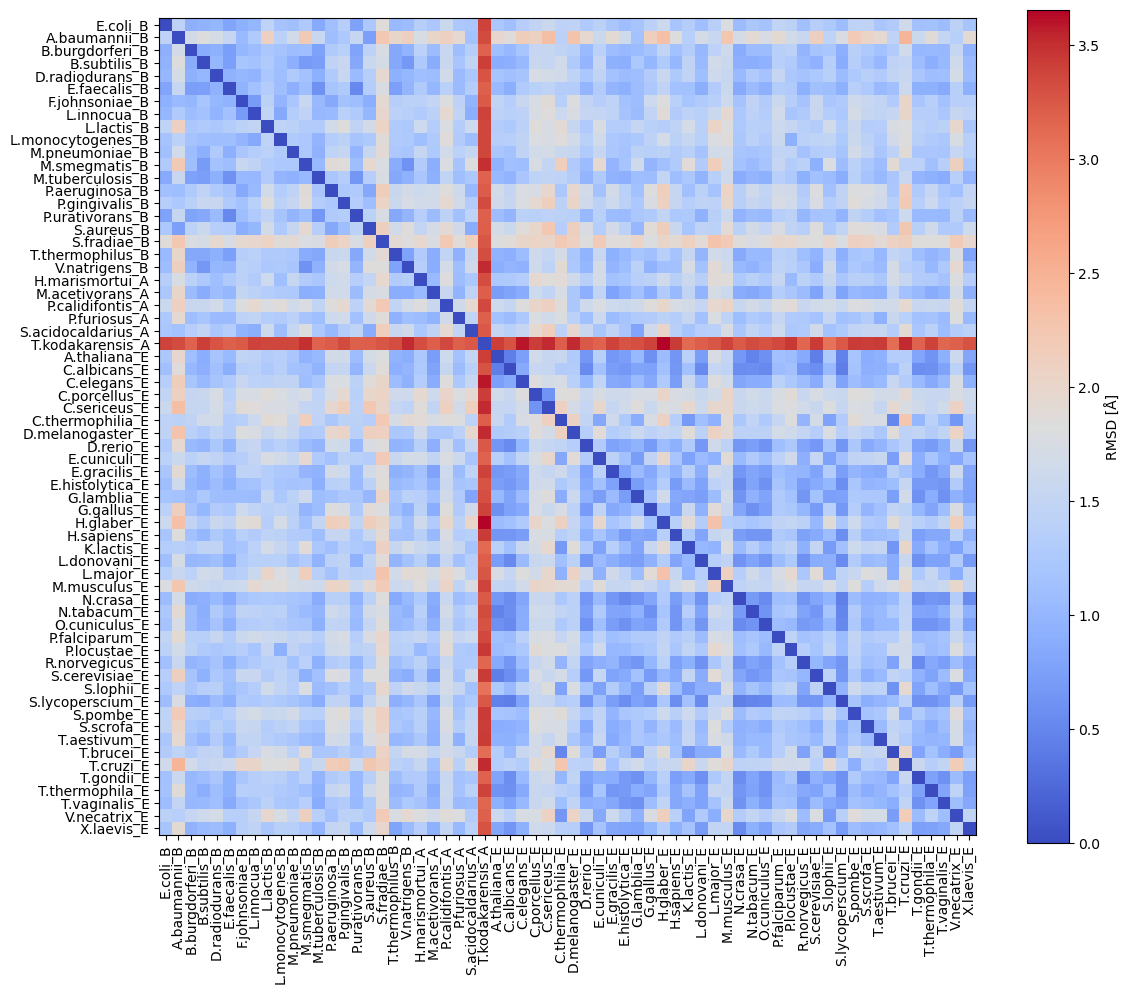

In [49]:
############
# Plotting #
############

plt.figure(figsize=(12, 10))

# Plot the heatmap
plt.imshow(rmsd_M, cmap="coolwarm")

# Set the ticks and labels
plt.yticks(ticks=np.arange(len(org_list)), labels=org_list)
plt.xticks(ticks=np.arange(len(org_list)), labels=org_list, rotation=90)

# Safe Angstrom symbol and title
plt.colorbar(label="RMSD [Å]")
#plt.title("Peptidyl Transferase Center (PTC) Structural RMSD Matrix", fontsize=16, pad=15)

# Ensure the long labels don't get cut off at the bottom!
plt.tight_layout()

# Display and save
output_name = "ptc_rmsd_matrix.svg"
plt.savefig(output_name)
plt.show()

In [50]:
rmsd_M[29,30]

np.float64(0.6391584277153015)

In [51]:
#############
# THE TREEE #
#############

In [52]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [53]:
condensed_matrix = squareform(rmsd_M)
linkage_matrix = linkage(condensed_matrix, method='average')

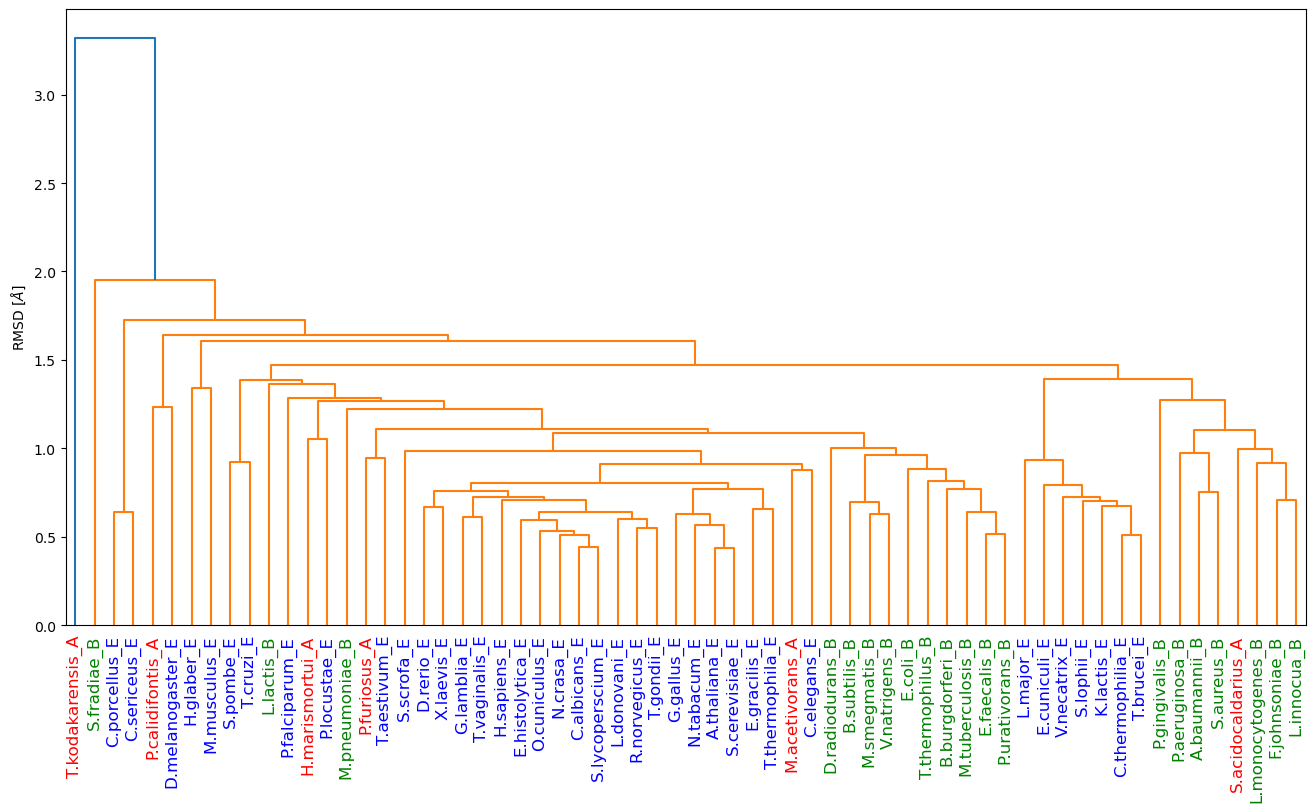

In [54]:
# Plot Dendrogram
plt.figure(figsize=(16, 8))
dendro = dendrogram(
    linkage_matrix, labels=org_list, leaf_rotation=90, leaf_font_size=12
)

# Get the correct leaf order from dendrogram
leaf_order = dendro['leaves']

# Apply leaf label colors based on reordered indices
ax = plt.gca()
xticklabels = ax.get_xmajorticklabels()

for i, label in enumerate(xticklabels):
    label.set_color(leaf_colors[leaf_order[i]])  # Map correct color

plt.ylabel("RMSD [$\AA$]")
plt.show()

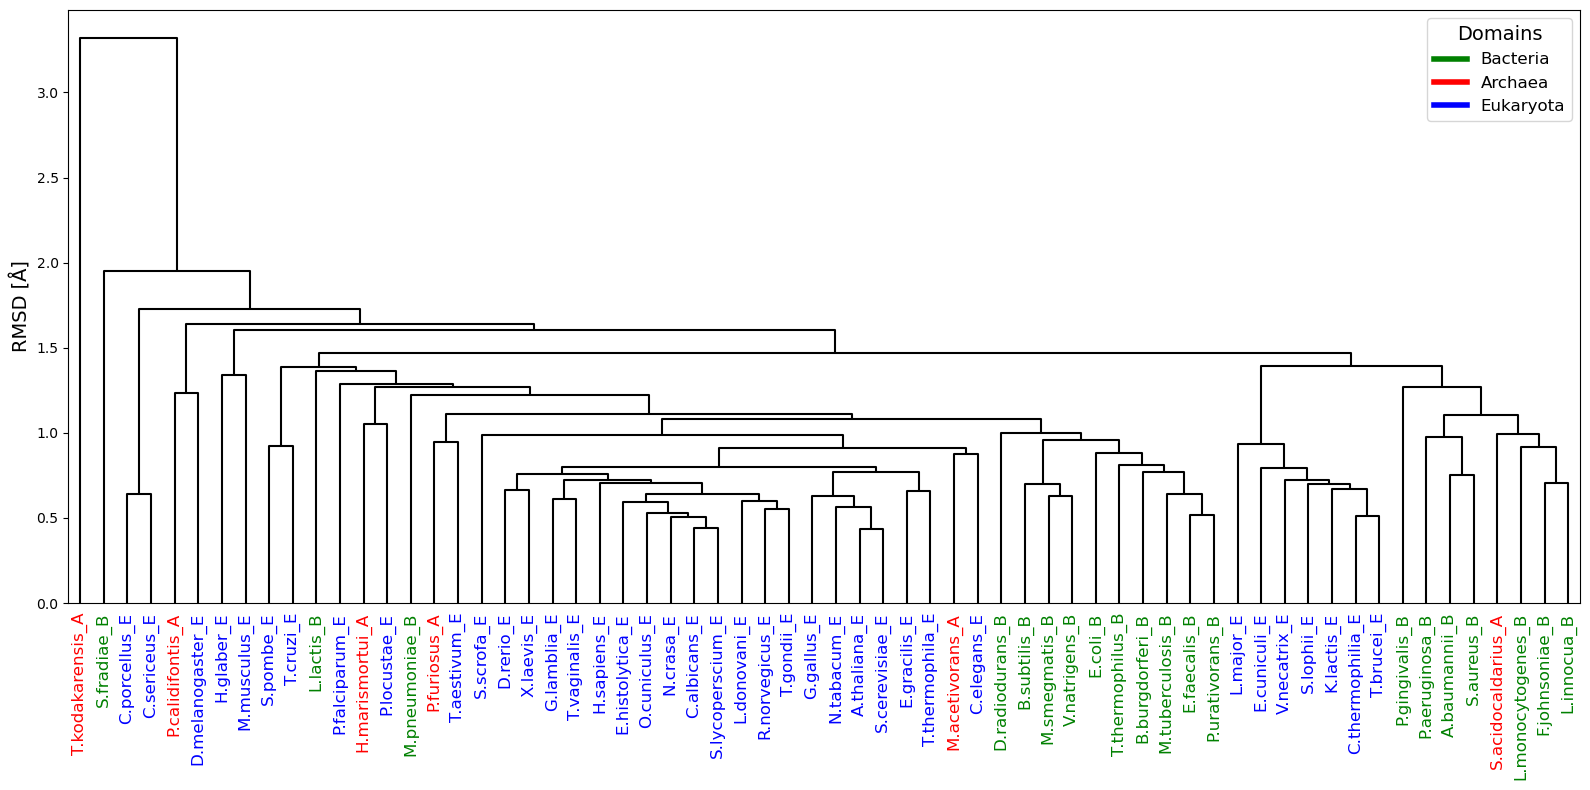

In [57]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# 1. Convert to a 1D condensed distance matrix and calculate linkage
condensed_matrix = squareform(rmsd_M)
# 'average' (UPGMA) is the standard clustering method for phylogenetic distances!
linkage_matrix = linkage(condensed_matrix, method='average')

# 2. Plot the Dendrogram
fig, ax = plt.subplots(figsize=(16, 8))
dendro = dendrogram(
    linkage_matrix, 
    labels=org_list, 
    leaf_rotation=90, 
    leaf_font_size=12,
    ax=ax,
    color_threshold=0,             # Forces all branches to be a single color
    above_threshold_color='black'  # Sets that branch color to black
)

# 3. Apply leaf label colors based on the reordered dendrogram indices
leaf_order = dendro['leaves']
xticklabels = ax.get_xmajorticklabels()

for i, label in enumerate(xticklabels):
    # leaf_order[i] maps the new X-axis position back to the original org_list index
    label.set_color(leaf_colors[leaf_order[i]])  

# 4. Create a custom legend for the biological domains
legend_elements = [
    Line2D([0], [0], color='green', lw=4, label='Bacteria'),
    Line2D([0], [0], color='red', lw=4, label='Archaea'),
    Line2D([0], [0], color='blue', lw=4, label='Eukaryota'),
    #Line2D([0], [0], color='yellow', lw=4, label='Chloroplast')
    # Line2D([0], [0], color='purple', lw=4, label='Mitochondria')
]
ax.legend(handles=legend_elements, loc='upper right', title="Domains", fontsize=12, title_fontsize=14)

# 5. Global Formatting
plt.ylabel("RMSD [Å]", fontsize=14)
#plt.title("Phylogenetic Clustering of the Peptidyl Transferase Center (PTC)", fontsize=18, pad=15)

# Ensures the rotated 90-degree labels aren't cut off at the bottom edge
plt.tight_layout() 

# 6. Save and Display
output_name = "ptc_dendrogram.svg"
plt.savefig(output_name)
plt.show()

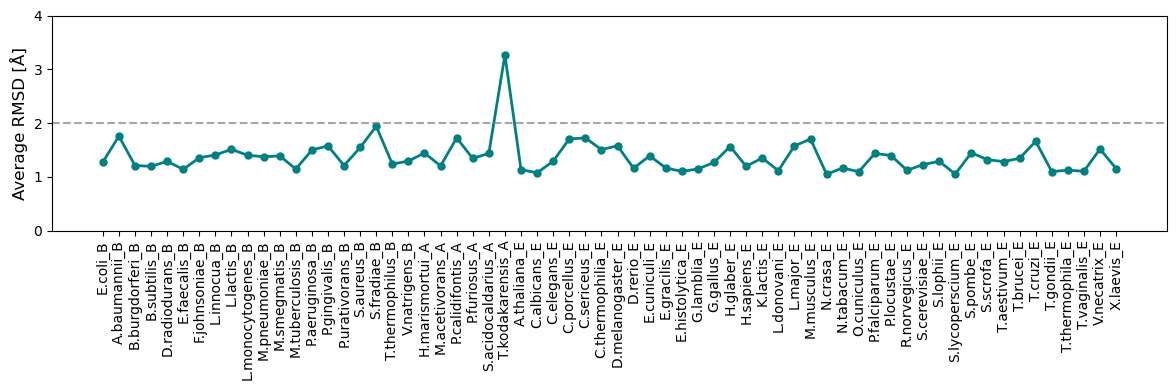

In [59]:
# Calculate Average RMSD using fast NumPy vectorization (No loops needed!)
# axis=0 calculates the mean down each column across the entire matrix instantly.
avg_rmsd = np.mean(rmsd_M, axis=0)

# Plotting
plt.figure(figsize=(12, 4))

# Added markers so individual organism values are distinctly visible on the line
plt.plot(avg_rmsd, lw=2, marker='o', markersize=5, color='teal')

# Set the ticks and labels safely
plt.xticks(ticks=np.arange(len(org_list)), labels=org_list, rotation=90)
plt.ylabel("Average RMSD [Å]", fontsize=12)

# Reference line and limits
plt.axhline(y=2.0, color='grey', ls='--', alpha=0.7)
plt.ylim(0, 4)

# Global formatting
#plt.title("Average PTC Structural Deviation per Organism", fontsize=14, pad=10)
plt.tight_layout() # Prevents the X-axis labels from getting chopped off!

# Save and Display
output_name = "ptc_avg_rmsd.svg"
plt.savefig(output_name)
plt.show()

In [ ]:
#########################################

In [28]:
# Mito Lmaj is too dificult to find corresponding PTC residues for many cases hence we removed it from the comparison

In [19]:
# Mitochondria ribosomes
org_data_mito = {
    "atha_M":{
        "pdb":"atha/6xyw_tunnel_fix.pdb","residues":{
            2058:2369,2059:2370,2061:2372,2063:2374,2251:2553,2252:2554,2447:2745,2450:2748,2451:2749,2453:2751,2499:2797,2501:2799,2506:2804,2553:2851,2572:2870,2583:2881,2585:2883,2602:2900
        }
    },
    "crei_M":{
        "pdb":"crei/7pkt_tunnel_fix.pdb","residues":{
            2058:408,2059:409,2061:411,2063:413,2251:540,2252:541,2447:92,2450:95,2451:96,2453:98,2499:144,2501:146,2506:151,2553:198,2572:217,2583:228,2585:np.nan,2602:247
        }
    },
    "hsap_M":{
        "pdb":"hsap/7qi4_tunnel_fix.pdb","residues":{
            2058:2721,2059:2722,2061:2724,2063:2726,2251:2815,2252:2816,2447:2934,2450:2937,2451:2938,2453:2940,2499:2986,2501:2988,2506:2993,2553:3040,2572:3059,2583:3070,2585:3072,2602:3089
        }
    },
    # Super inne PTC... praktycznie zero oczywistego pokrywania sie moze poza ostatnimi 3 pozycjami.
    #"lmaj":{
    #    "pdb":"lmaj/_tunnel_fix.pdb","residues":{
    #        2058:872,2059:873,2061:875,2063:876,2251:,2252:,2447:,2450:,2451:,2453:,2499:,2501:,2506:,2553:,2572:,2583:,2585:,2602:
    #    }
    #},
    "ncra_M":{
        "pdb":"ncra/6ywy_tunnel_fix.pdb","residues":{
            2058:2293,2059:2294,2061:2296,2063:2298,2251:2453,2252:2454,2447:2897,2450:2900,2451:2901,2453:2903,2499:2950,2501:2952,2506:2957,2553:3005,2572:3024,2583:3035,2585:3037,2602:3054
        }
    },
    "pmag_M":{
        "pdb":"pmag/8apn_tunnel_fix.pdb","residues":{
            2058:351,2059:352,2061:354,2063:356,2251:449,2252:450,2447:35,2450:38,2451:39,2453:41,2499:86,2501:88,2506:93,2553:140,2572:159,2583:170,2585:172,2602:189
        }
    },
    # Major difference within 2251,2252 region whoch would highly dominated the RMSD matrix so we exluded - rest is similar especially 2447>=
    #"scer":{
    #    "pdb":"scer/5mrc_tunnel_fix.pdb","residues":{
    #        2058:1958,2059:1959,2061:1961,2063:1963,2251:,2252:,2447:,2450:,2451:,2453:,2499:,2501:,2506:,2553:,2572:,2583:,2585:,2602:
    #    }
    #},
    #"sscr_M":{
    #    "pdb":"sscr/6ydp_tunnel_fix.pdb","residues":{
    #        2058:1053,2059:1054,2061:1056,2063:1058,2251:1151,2252:1152,2447:1270,2450:1273,2451:1274,2453:1276,2499:1322,2501:1324,2506:1329,2553:1376,2572:1395,2583:1406,2585:1408,2602:1425
    #    }
    #},
    # The PTC I think was not not resolved and they used homology model for visualisation purpose
    #"tbru":{ 
    #    "pdb":"lmaj/_tunnel_fix.pdb","residues":{
    #        2058:,2059:,2061:,2063:,2251:,2252:,2447:,2450:,2451:,2453:,2499:,2501:,2506:,2553:,2572:,2583:,2585:,2602:
    #    }
    #},
    # Again PTC with significant changes
    #"tgon":{
    #    "pdb":"lmaj/_tunnel_fix.pdb","residues":{
    #        2058:,2059:,2061:,2063:,2251:,2252:,2447:,2450:,2451:,2453:,2499:,2501:,2506:,2553:,2572:,2583:,2585:,2602:
    #    }
    #},
    "tthe_M":{
        "pdb":"tthe/6z1p_tunnel_fix.pdb","residues":{
            2058:1777,2059:1778,2061:1780,2063:1782,2251:1945,2252:1946,2447:2141,2450:2144,2451:2145,2453:2147,2499:2193,2501:2195,2506:2200,2553:2247,2572:2266,2583:2277,2585:2279,2602:2296
        }
    }
}

In [9]:
    "ecoli":{
        "pdb":"ecoli/ecoli_tunnel_fix.pdb","residues":{
            2058:,2059:,2061:,2063:,2251:,2252:,2447:,2450:,2451:,2453:,2499:,2501:,2506:,2553:,2572:,2583:,2585:,2602:
        }
    }

SyntaxError: expression expected after dictionary key and ':' (4291355969.py, line 3)

In [27]:
# Chloroplast ribosomes PTC mapping
org_data_chloro = {
    "chloro": {
        "pdb": "chloro/5x8p_tunnel_fix.pdb",
        "residues": {2058:2072, 2059:2073, 2061:2075, 2063:2077, 2251:2268, 2252:2269, 2447:2464, 2450:2467, 2451:2468, 2453:2470, 2499:2516, 2501:2518, 2506:2523, 2553:2570, 2572:2589, 2583:2599, 2585:np.nan, 2602:2619}
    }
}

In [33]:
np.shape(rmsd_M)

(55, 55)

In [34]:
ii =1
org_list[ii],np.mean(rmsd_M[:,ii])

('A.baumannii_B', 1.718563933805986)

In [35]:
ii=0
org_list[ii],np.mean(rmsd_M[:,ii])

('E.coli_B', 1.255113795670596)

In [36]:
rmsd_M[0,1]

1.4340623617172241

In [37]:
rmsd_M[:,35][30]

1.5660032033920288

In [38]:
ii=5
org_list[ii],np.mean(rmsd_M[:,ii])

('E.faecalis_B', 1.1207083463668823)

In [39]:
rmsd_M[44,48]

1.0861196517944336

In [38]:
np.mean(rmsd_M[:,21])

3.240438422849101

In [41]:
np.mean(rmsd_M[:,55])

2.1514044557848284

In [33]:
org_data["saur"]

NameError: name 'org_data' is not defined

In [32]:
list(ecoli.values())

[2058,
 2059,
 2061,
 2063,
 2251,
 2252,
 2447,
 2450,
 2451,
 2453,
 2499,
 2501,
 2506,
 2553,
 2572,
 2583,
 2585,
 2602]

In [ ]:
A2058 -> 1053
A2059 -> 1054
G2061 -> 1056
C2063 -> 1058
G2251 -> 1151
G2252 -> 1152
G2447 -> 1270
A2450 -> 1273
A2451 -> 1274
A2453 -> 1276
C2499 -> 1322
C2501 -> 1324
U2506 -> 1329
G2553 -> 1376
A2572 -> 1395
U2583 -> 1406
U2585 -> 1408
A2602 -> 1425

In [ ]:
set a [atomselect 0 "backbone and resid 2058 2059 2061 2063 2251 2252 2447 2450 2451 2453 2499 2501 2506 2553 2572 2583 2585 2602"]

set b [atomselect top "backbone and resid 2293 2294 2296 2298 2453 2454 2897 2900 2901 2903 2950 2952 3005 3024 3035 3037 3054"]

set b [atomselect top "backbone and resid 3904 3905 3907 3909 4196 4197 4393 4396 4397 4399 4445 4447 4452 4499 4518 4529 4531 4548"]

In [17]:
list = []
N=27
for i in [2058, 2059, 2061, 2063,2251, 2252, 2447, 2450, 2451, 2453, 2499, 2501, 2506, 2553, 2572, 2583, 2585, 2602]:
    list.append(i+N)

In [18]:
list

[2085,
 2086,
 2088,
 2090,
 2278,
 2279,
 2474,
 2477,
 2478,
 2480,
 2526,
 2528,
 2533,
 2580,
 2599,
 2610,
 2612,
 2629]

In [19]:
# Create the selection string for set a
selection_string = "set b [atomselect top \"backbone and resid "
for residue in list:
  selection_string += str(residue) + " "

selection_string = selection_string[:-1] + "\"]"

# Print the final output
print(selection_string)

set b [atomselect top "backbone and resid 2085 2086 2088 2090 2278 2279 2474 2477 2478 2480 2526 2528 2533 2580 2599 2610 2612 2629"]


In [ ]:
Ecoli vs Bacteria
a.bau -> 1.48A
b.bur -> 1.12A
b.sub -> 1.08A
c.acn -> 1.17A
d.rad -> 1.12A
e.fae -> 0.97A
f.joh -> 1.08A
l.inn -> 1.13A
l.lac -> 1.60A
l.mon -> 1.27A
m.pne -> 1.34A
m.sme -> 1.38A
m.tub -> 1.00A
p.aer -> 1.30A
p.ura -> 0.96A
s.aur -> 1.45A
t.the -> 1.19A
4ybb -> 1.09A

In [ ]:
Ecoli vs Eukaryota
c.alb -> 1.33A
c.the -> 1.57A
d.mel -> 2.19A
d.rer -> 1.43A
e.cun -> 1.58A
e.gra -> 1.42A
g.lam -> 1.25A [missing 2602]
h.sap -> 1.40A
k.lac -> 1.45A
l.don -> 1.52A [missing 2453]
m.mus -> 1.95A
n.cra -> 1.23A
n.tab -> 1.40A
o.cun -> 1.38A
p.fal -> 1.73A
p.loc -> 1.54A
s.cer -> 1.50A
s.lop -> 1.42A
s.lyc -> 1.28A
s.pom -> 1.58A
s.scr -> 1.63A
t.aes -> 1.33A
t.bru -> 1.50A
t.cru -> 1.78A
t.gon -> 1.30A
t.the -> 1.35A
t.vag -> 1.20A

In [ ]:
Ecoli vs Archaea
h.mar -> 1.43A
p.fur -> 1.34A
s.aci -> 1.66A
t.kod -> 3.48A [bizzare RNA structure around e.coli A2059,G2061...] without it is 1.93A

In [ ]:
Ecoli vs Chloroplast
chloro -> 3.00A [so many shifts in the RNA structure...]

In [ ]:
Ecoli vs mitochondria
a.tha -> 1.33A
h.sap -> 1.10A
l.maj -> 5.0A [missing region after 2061 corresponding to 875 876; not really corresponding nucleotides to 2251 and 2252, 2501, 2572, 2602] - very strange ribosome...
n.cra -> 2.21A [region corresponding to 2501 - 2506 is missing]
p.mag -> 1.16A
s.cer -> 3.03A [fragment corresponding to 2251 and 2252, 2450, 2451, 2501 is missing]
s.scr -> 1.03A